In [ ]:
# Libs
import phobos
import numpy as np
import matplotlib.pyplot as plt
import json
import time
import pickle
from tqdm import tqdm

✅ BMC lib found. Running in control mode.


fatal: not a git repository (or any of the parent directories): .git


In [2]:
# Constants
lam = 1550 # [nm]

In [3]:
# shortcuts
dm = phobos.DM()
cam = phobos.Cred3()
chip = phobos.Arch6()
inj_seg = phobos.Config().get('injection.segments')
print('Injected segments:', inj_seg)

# Setup
path = phobos.archive.new('ABCD_fringe_tracking', verbose=True)


DEBUG - SDK Install Path: /opt/Boston Micromachines
DEBUG - BMC_PCIeOpenDM 27BW007#051 0
DEBUG - 1 BMC PCIe cards installed.
DEBUG - Using automatic devId: 1
DEBUG - BMC_PCIeOpenDM opening 0
INFO - PCIe HW Rev: 20000502
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
INFO - Loading calibration for DM: 27BW07#051_5_3_setof14
DEBUG - Loading map file: /opt/Boston Micromachines/Map/KILO507.map expected count: 1024
Cred3 camera initialized with dark subtraction
Injected segments: [138, 137, 136, 135]
Archive created at /mnt/disk1/archive/2026-03-18/4_ABCD_fringe_tracking


Scanning injection maps:   0%|          | 0/4 [00:00<?, ?it/s]

  Channel 0 (segment 138): scanning…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])


Scanning injection maps:  25%|██▌       | 1/4 [00:15<00:46, 15.58s/it]

Injection OFF on channels [0] (segments [138])
  Channel 1 (segment 137): scanning…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])


Scanning injection maps:  50%|█████     | 2/4 [00:30<00:30, 15.39s/it]

...

Scanning injection maps:  75%|███████▌  | 3/4 [00:45<00:15, 15.01s/it]

Injection OFF on channels [2] (segments [136])
  Channel 3 (segment 135): scanning…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])


Scanning injection maps: 100%|██████████| 4/4 [01:00<00:00, 15.24s/it]

Injection OFF on channels [3] (segments [135])
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])

── Find gross TT for max injection and spread ──
Injection max of seg=138: (tip, tilt) = (-0.80669,0.09340) mrad
Injection spread of seg=138: (tip, tilt) = (0.62915,0.75613) mrad
Injection max of seg=137: (tip, tilt) = (-0.34332,-0.02860) mrad
Injection spread of seg=137: (tip, tilt) = (0.74646,0.68724) mrad
Injection max of seg=136: (tip, tilt) = (-0.00626,-0.18852) mrad
Injection spread of seg=136: (tip, tilt) = (0.67629,0.76381) mrad
Injection max of seg=135: (tip, tilt) = (0.20227,-0.17145) mrad
Injection spread of seg=135: (tip, tilt) = (0.70390,0.79072) mrad

── Find precise TT for max injection ──
Injection max of seg=138: (tip, tilt) = (-0.80976,0.11174) mrad; flux = 560.4
Injection max of seg=137: (tip, tilt) = (-0.35974,-0.02281) mrad; flux = 618.8
Injection max of seg=136: (tip, tilt) = (-0.01535,-0.17847) mrad; flux = 609.8
Injection max of seg=135: (tip, 


── Finding maximum injection points ──

── Balancing injection fluxes ──
  Weakest channel: 2 (seg 136), target flux = 552.9
  Dichotomy on channel 0 (seg 138)…
Injection OFF on channels [1, 2, 3] (segments [137, 136, 135])
    → balanced tilt = 0.2802 mrad, flux = 548 (target 552.9), iterations = 12
  Dichotomy on channel 1 (seg 137)…
Injection OFF on channels [0, 2, 3] (segments [138, 136, 135])
    → balanced tilt = 0.3461 mrad, flux = 547.6 (target 552.9), iterations = 12
  Dichotomy on channel 3 (seg 135)…
Injection OFF on channels [0, 1, 2] (segments [138, 137, 136])
    → balanced tilt = 0.2363 mrad, flux = 547.1 (target 552.9), iterations = 12
Injection FLAT on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
✅ Injection calibration saved to config (injection.balanced)


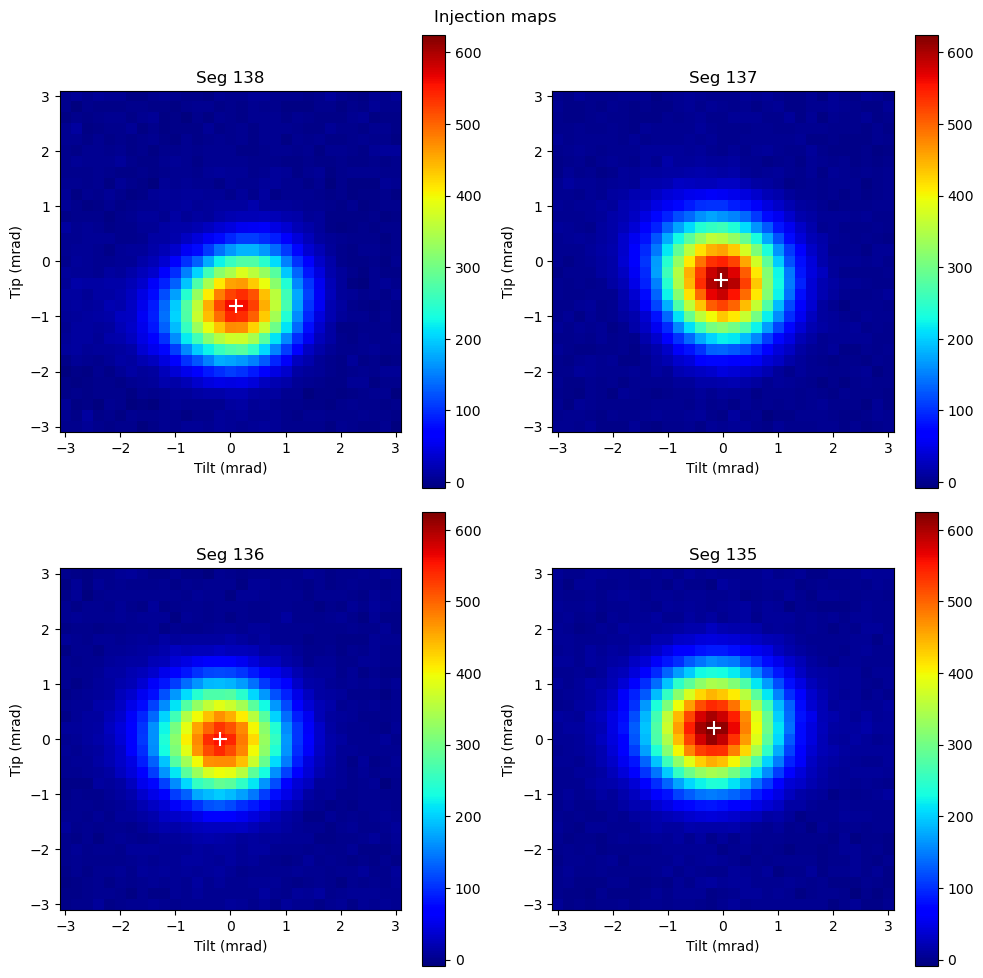

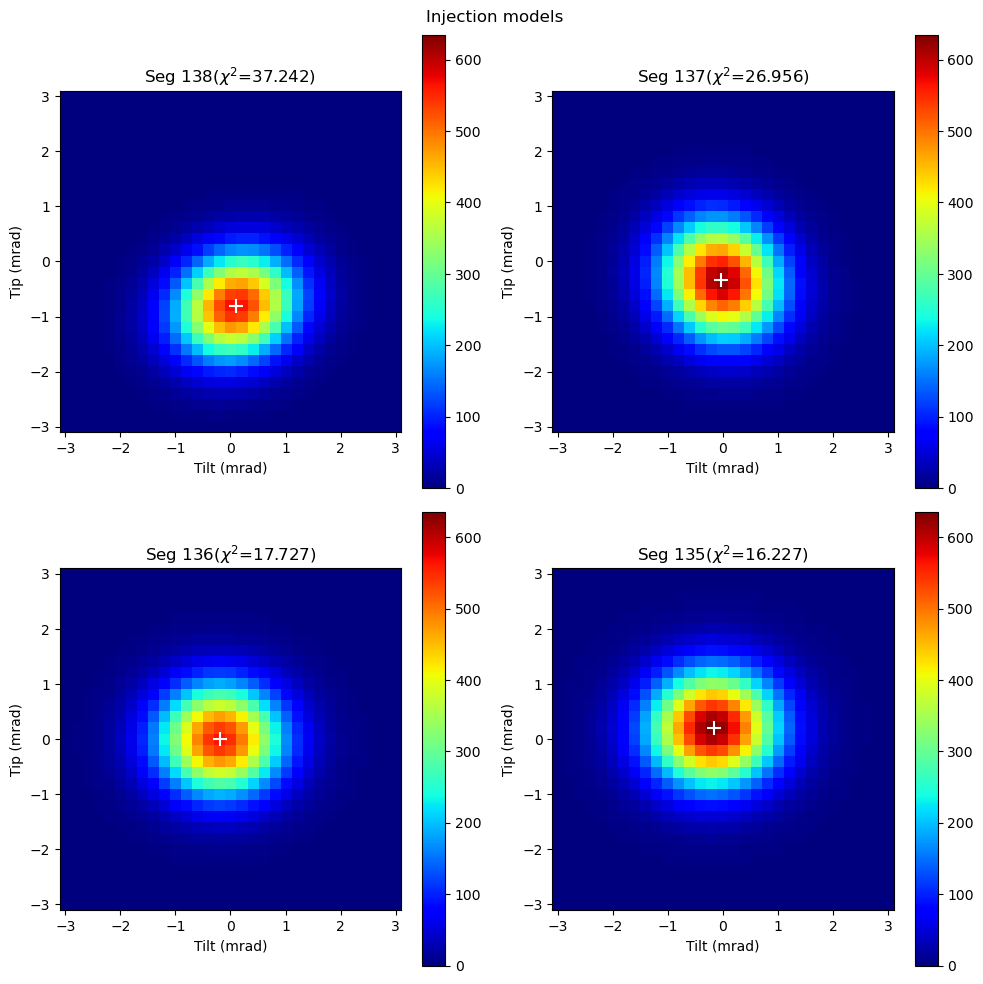

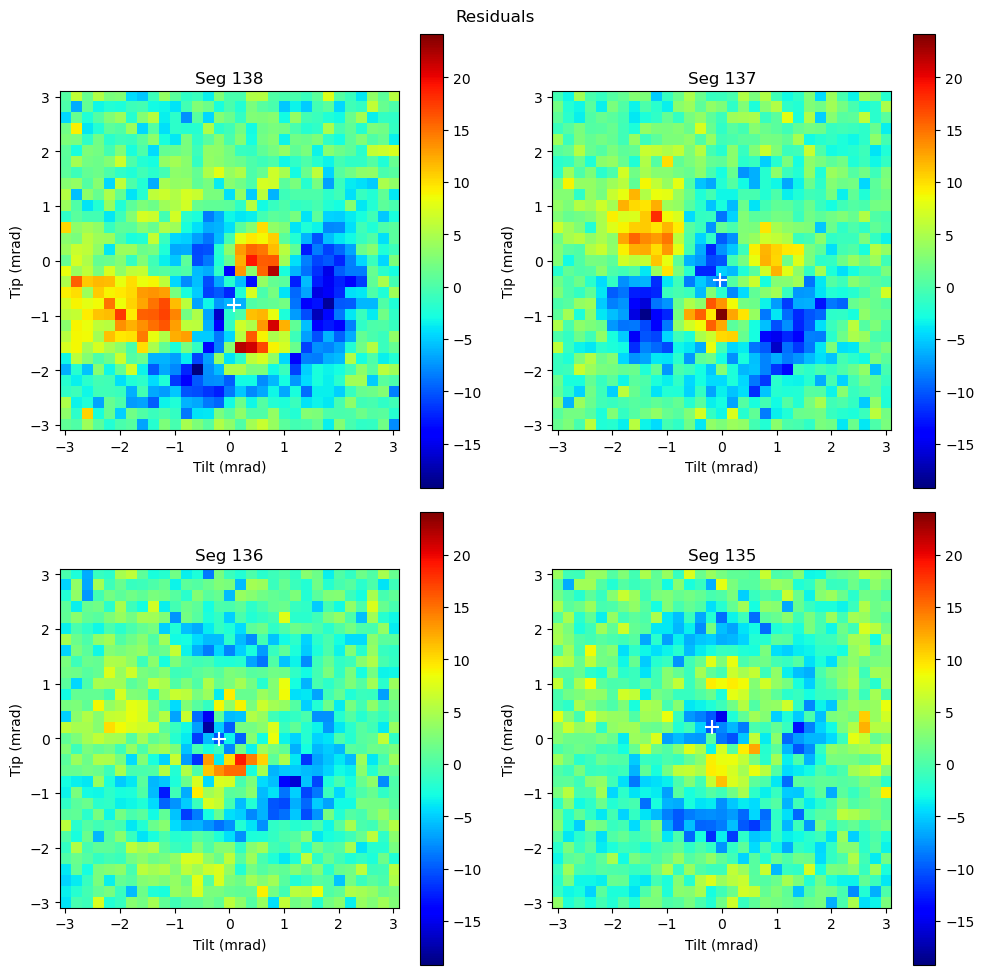

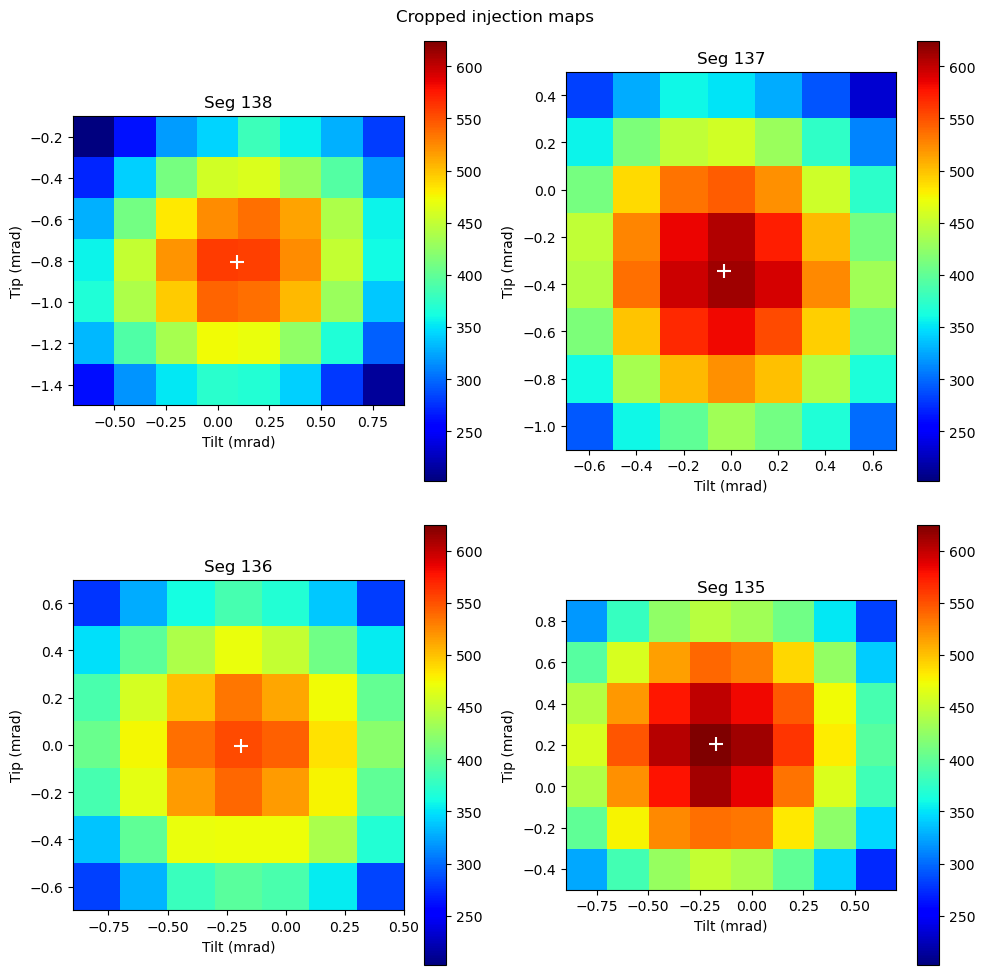

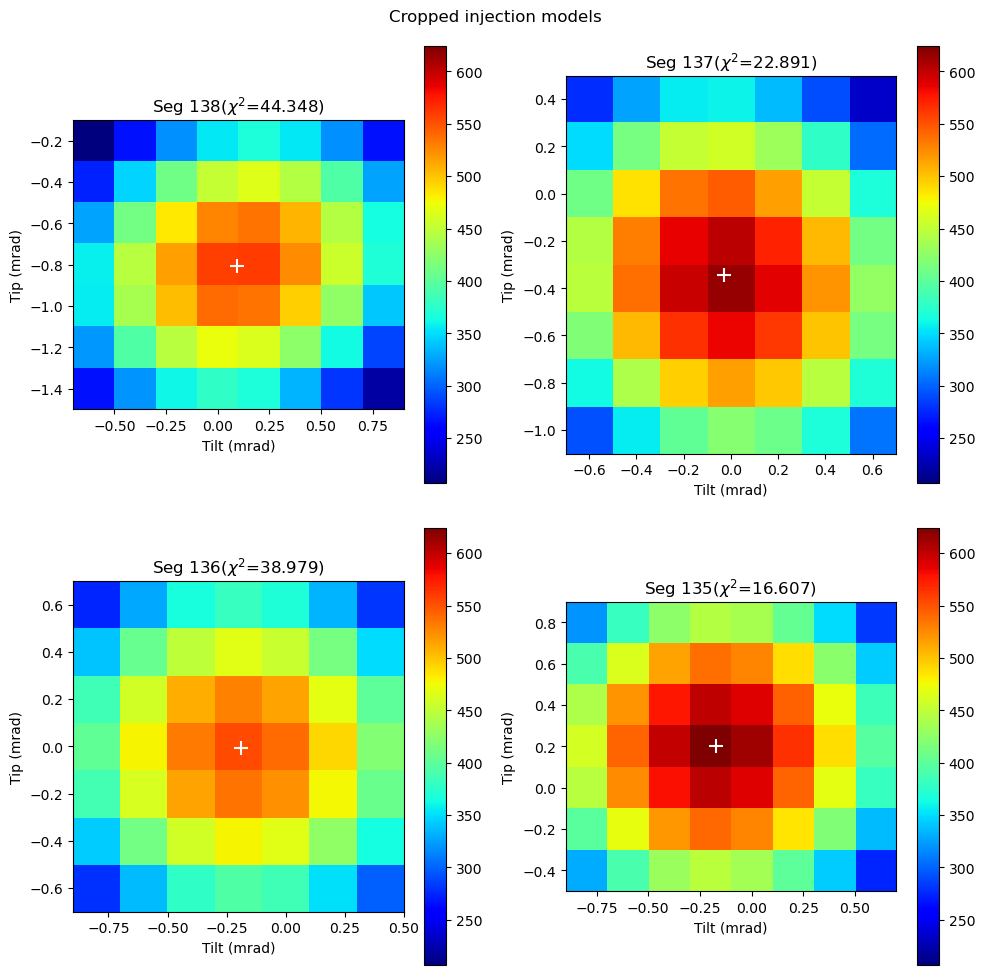

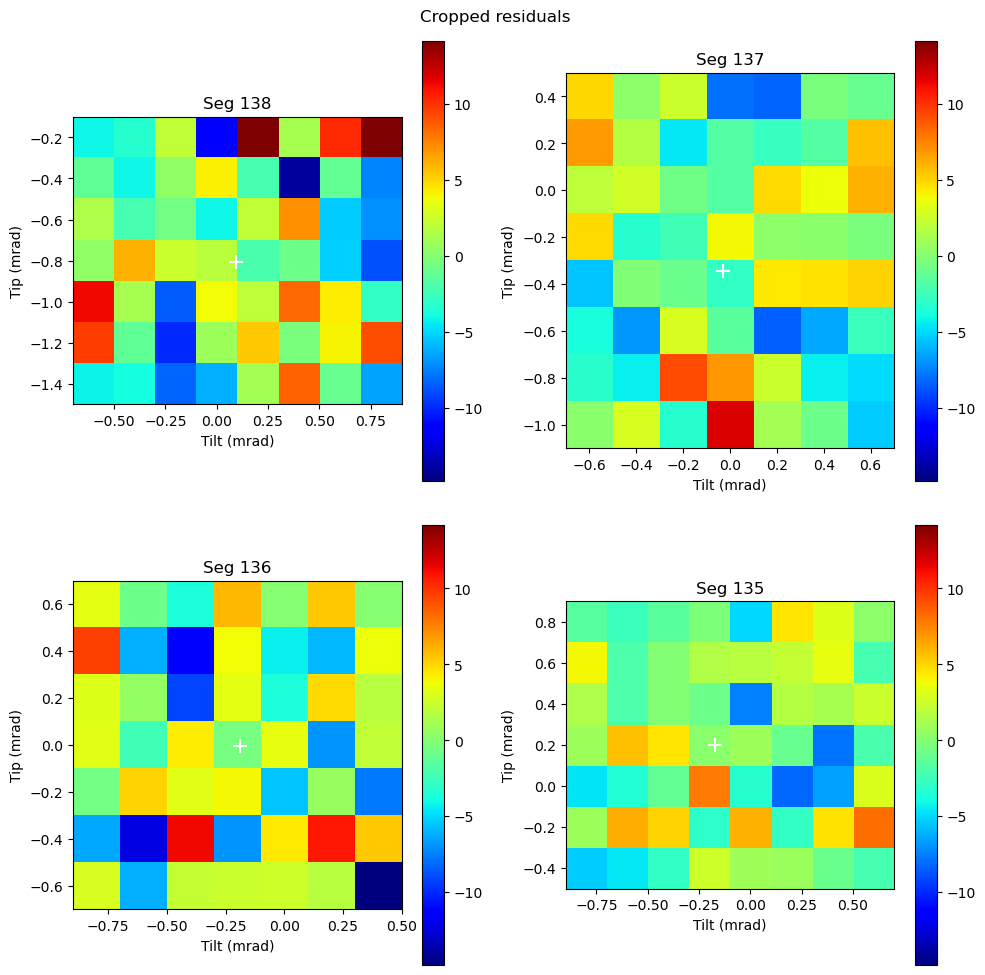

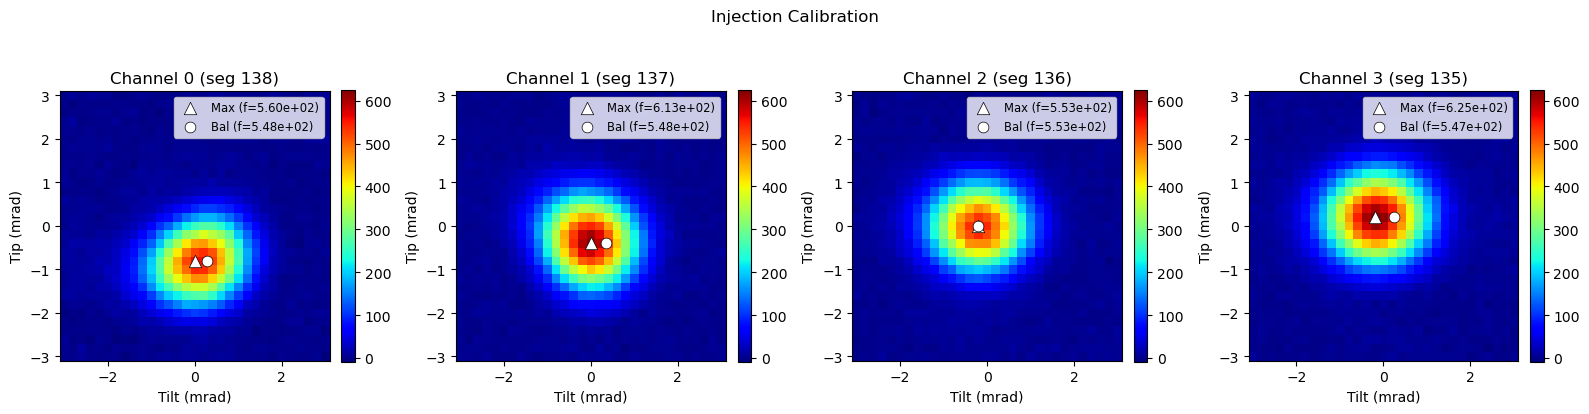

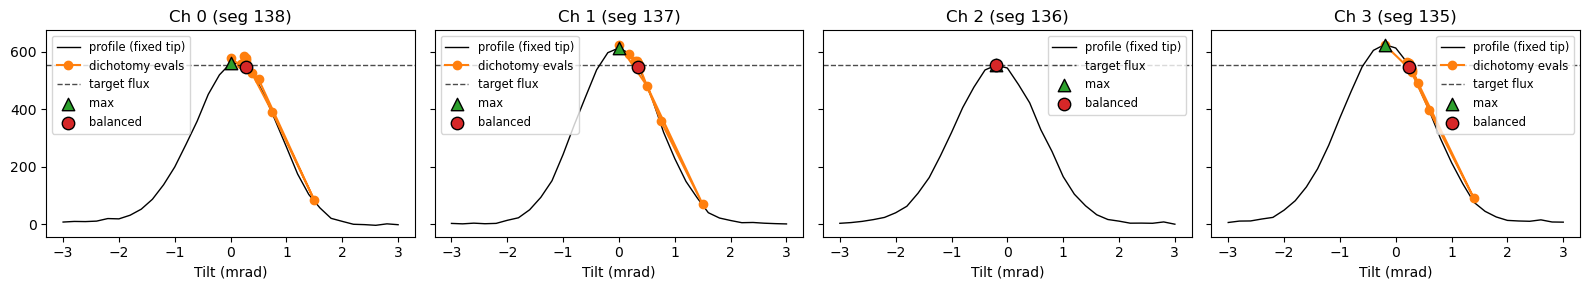

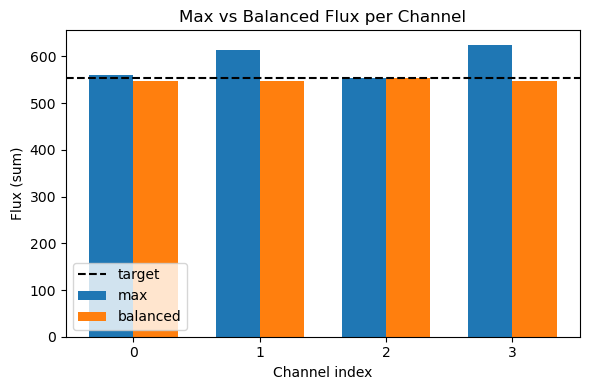

Successfully saved in FITS
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


In [10]:
# Injection calibration
inj = phobos.Injection()
avg_frame = 5
out_inj = inj.calibrate(verbose=True, plot=True, save_path=path)

inj.set_balanced()



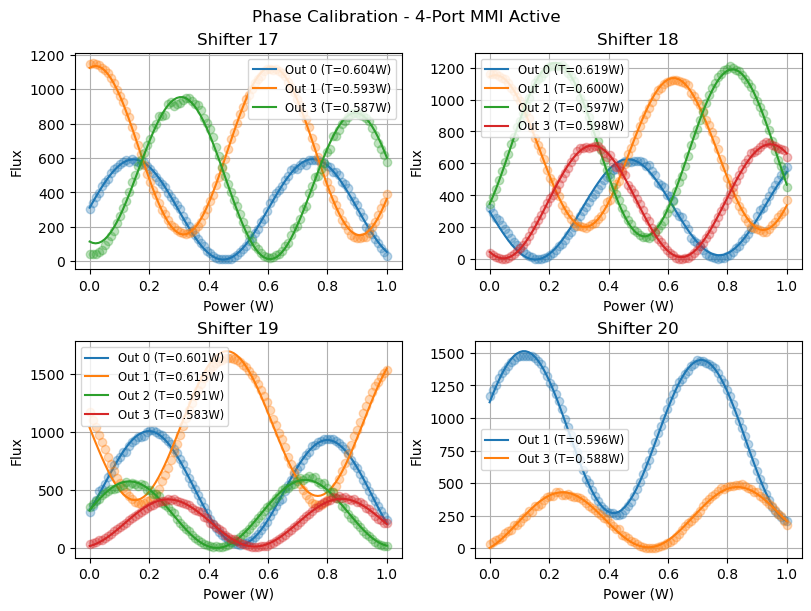

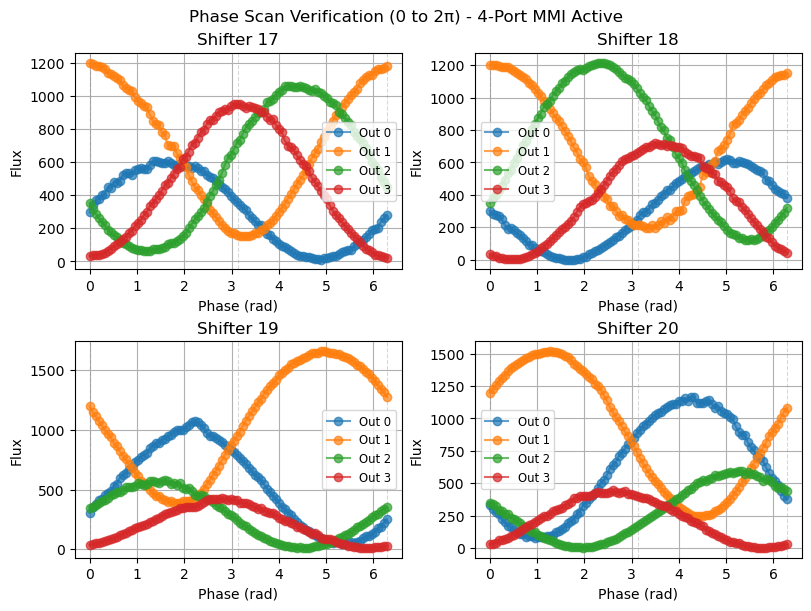

array([[[ 305.17495728, 1145.18457031,  374.31417847,   44.04087067],
        [ 338.35714722, 1152.63342285,  326.13195801,   40.20976257],
        [ 372.23718262, 1146.26904297,  281.87863159,   44.92087173],
        ...,
        [  79.15719604,  308.60235596, 1122.61633301,  651.55194092],
        [  51.69052887,  346.64682007, 1129.4342041 ,  616.36535645],
        [  33.59719467,  393.18902588, 1134.52307129,  574.46313477]],

       [[ 322.65936279, 1157.38012695,  343.23416138,   39.32531738],
        [ 292.28607178, 1162.35351562,  389.51416016,   23.64087296],
        [ 260.59719849, 1160.19787598,  440.99859619,   14.25864983],
        ...,
        [ 527.02832031,  284.84680176,  581.50976562,  690.02752686],
        [ 556.3527832 ,  303.9312439 ,  527.85192871,  684.64526367],
        [ 576.81054688,  371.91790771,  452.82971191,  639.03204346]],

       [[ 314.15270996, 1169.10900879,  357.30526733,   32.91198349],
        [ 362.9838562 , 1100.73571777,  376.02972412,   43.6

In [11]:
# TOPAs calibration
chip.phase_calibration(plot=True, verbose=False)

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0] (segments [138])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1] (segments [137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [2] (segments [136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [3] (segments [135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


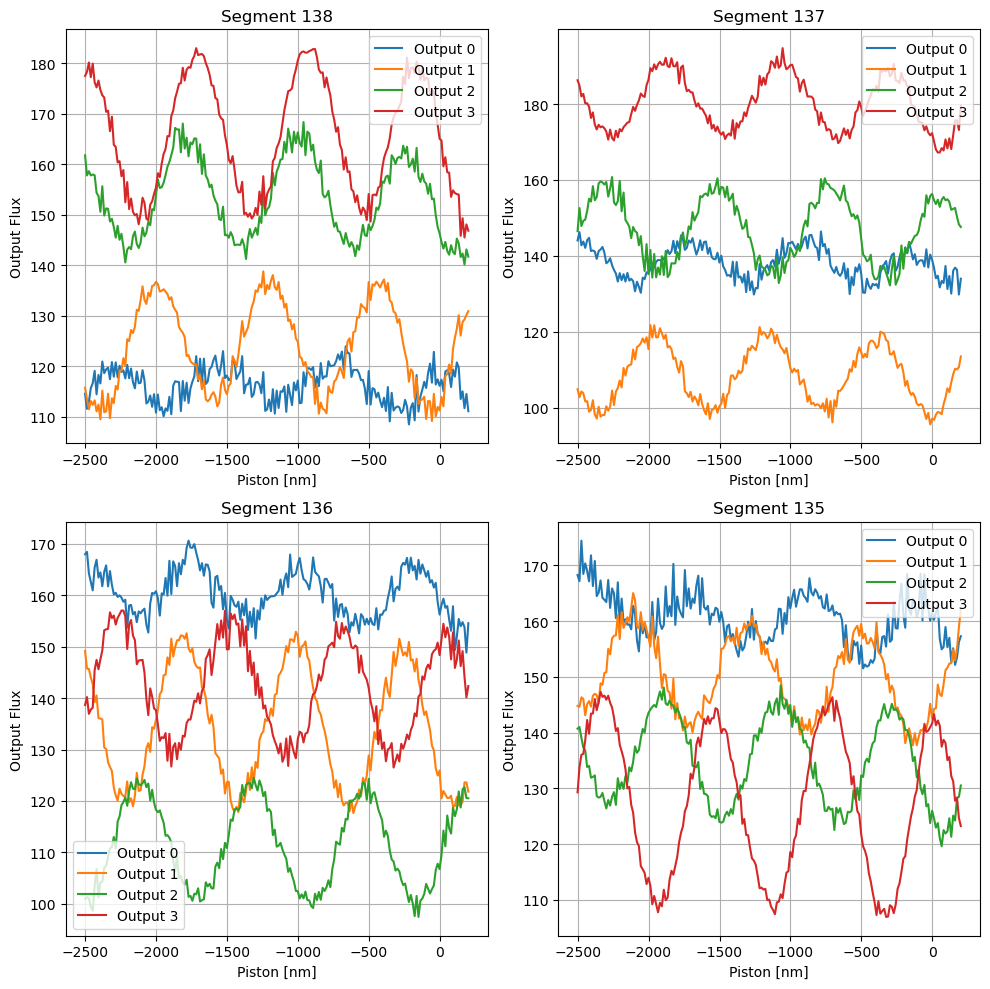

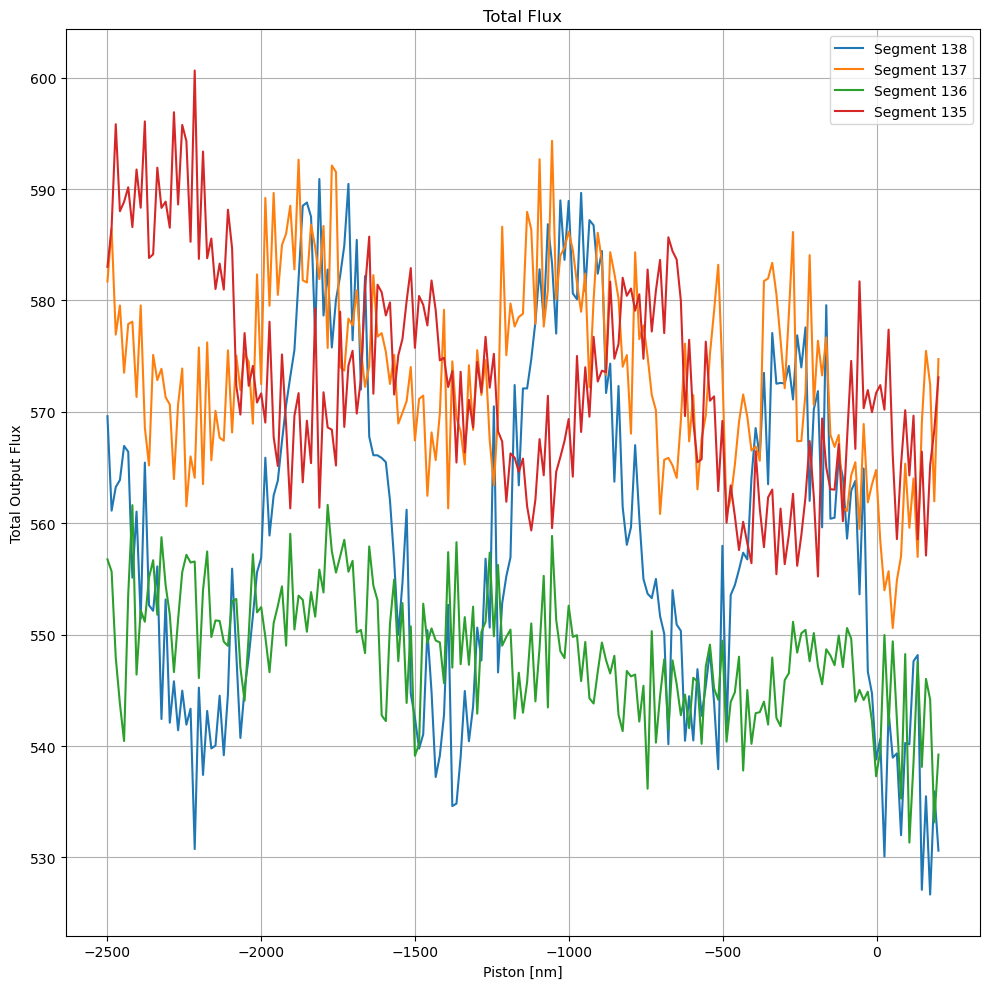

In [12]:
# Single scan
piston_range = np.linspace(-2500, 200, 201)  # [nm]
n_ch = len(inj_seg)
res_single_scan = {}
fig, axs = plt.subplots(2, 2, figsize=(10, 10))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

total_flux = []
for beam in range(n_ch):
    inj.off()
    inj.set_balanced(beam)

    outs = np.empty((len(piston_range), 4))
    for p, opd in enumerate(piston_range):
        dm[inj_seg[beam]].set_piston(opd)
        outs[p] = cam.get_outputs(flux_mode='mean')

    res_single_scan[inj_seg[beam]] = outs.copy()
    total_flux.append(outs[:].sum(axis=1))

    for o in range(4):
        axs[beam].plot(piston_range, outs[:, o], color=colors[o], linestyle='-', label=f'Output {o}')

    axs[beam].set_title(f'Segment {inj_seg[beam]}')
    axs[beam].set_xlabel('Piston [nm]')
    axs[beam].set_ylabel('Output Flux')
    axs[beam].legend()
    axs[beam].grid()


fig.tight_layout()
fig.savefig(path / 'single_scan.png')

total_flux = np.array(total_flux)
fig, axs = plt.subplots(1, 1, figsize=(10, 10))

for o in range(4):
    axs.plot(piston_range, total_flux[o], color=colors[o], linestyle='-', label=f'Segment {inj_seg[o]}')

axs.set_title('Total Flux')
axs.set_xlabel('Piston [nm]')
axs.set_ylabel('Total Output Flux')
axs.legend()
axs.grid()
fig.tight_layout()
fig.savefig(path / 'single_scan_totalflux.png')

inj.set_balanced()


# Pair scan

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BA

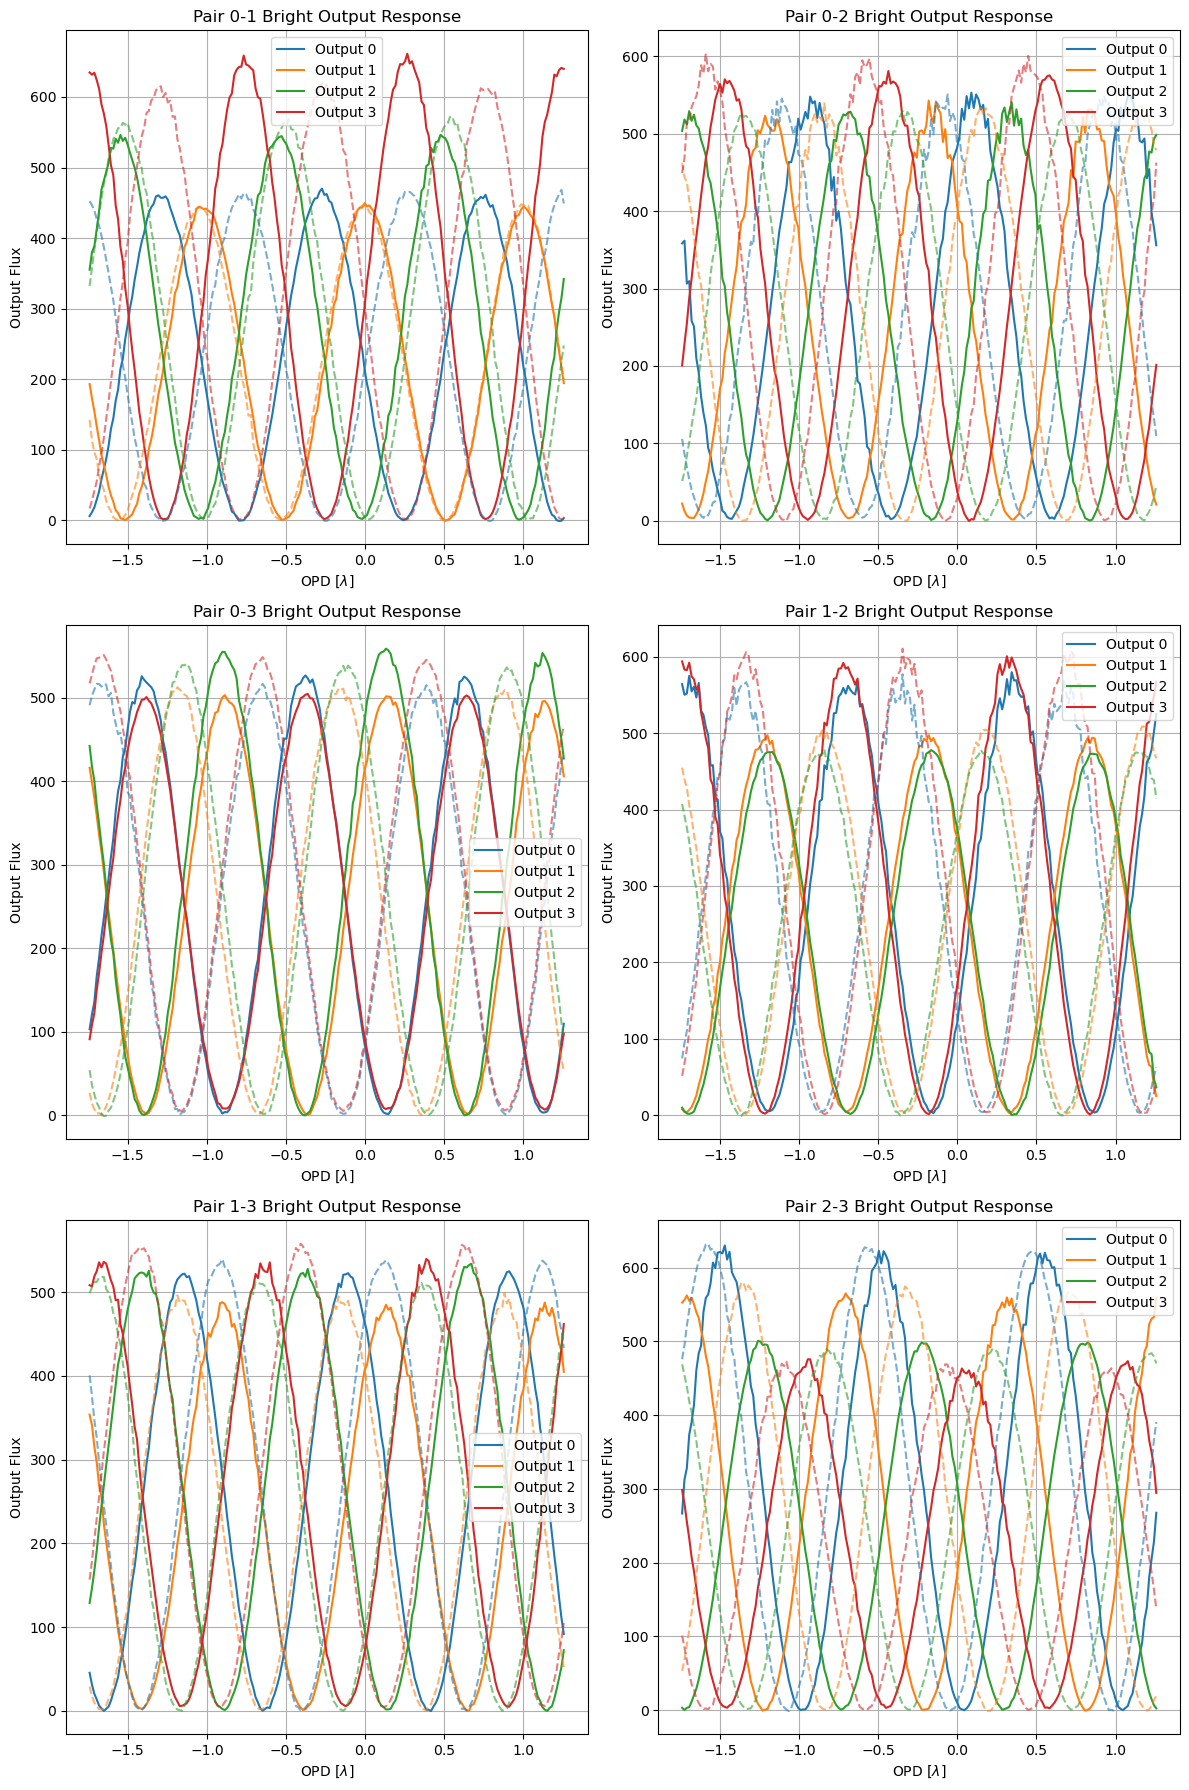

In [17]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
start = -2500 # nm
nb_lam = 3.

piston_range = np.linspace(start, start + nb_lam * lam/2., 201)  # [nm]


res_pair_scan = {}

fig, axs = plt.subplots(3, 2, figsize=(12, 18))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):
    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2

    dm[inj_seg[pair[1]]].set_piston(ref_cart)
    # Scan on first input
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[0]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[0], pair[1])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')

    # Scan on second input
    inj.off()
    inj.set_balanced(np.array(pair))

    dm[inj_seg[pair[0]]].set_piston(ref_cart)
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        dm[inj_seg[pair[1]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_pair_scan[(pair[1], pair[0])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], linestyle='--', alpha=0.6)
    
    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()

fig.tight_layout()
fig.savefig(path / 'pair_scan.png')

with open(path / 'pair_scan_data.pkl', 'wb') as f:
    pickle.dump(res_pair_scan, f)


inj.set_balanced()

# Piston ramp with counter phase shift

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 1] (segments [138, 137])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 2] (segments [138, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [0, 3] (segments [138, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 2] (segments [137, 136])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [2, 3] (segments [136, 135])
Injection BALANCED on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


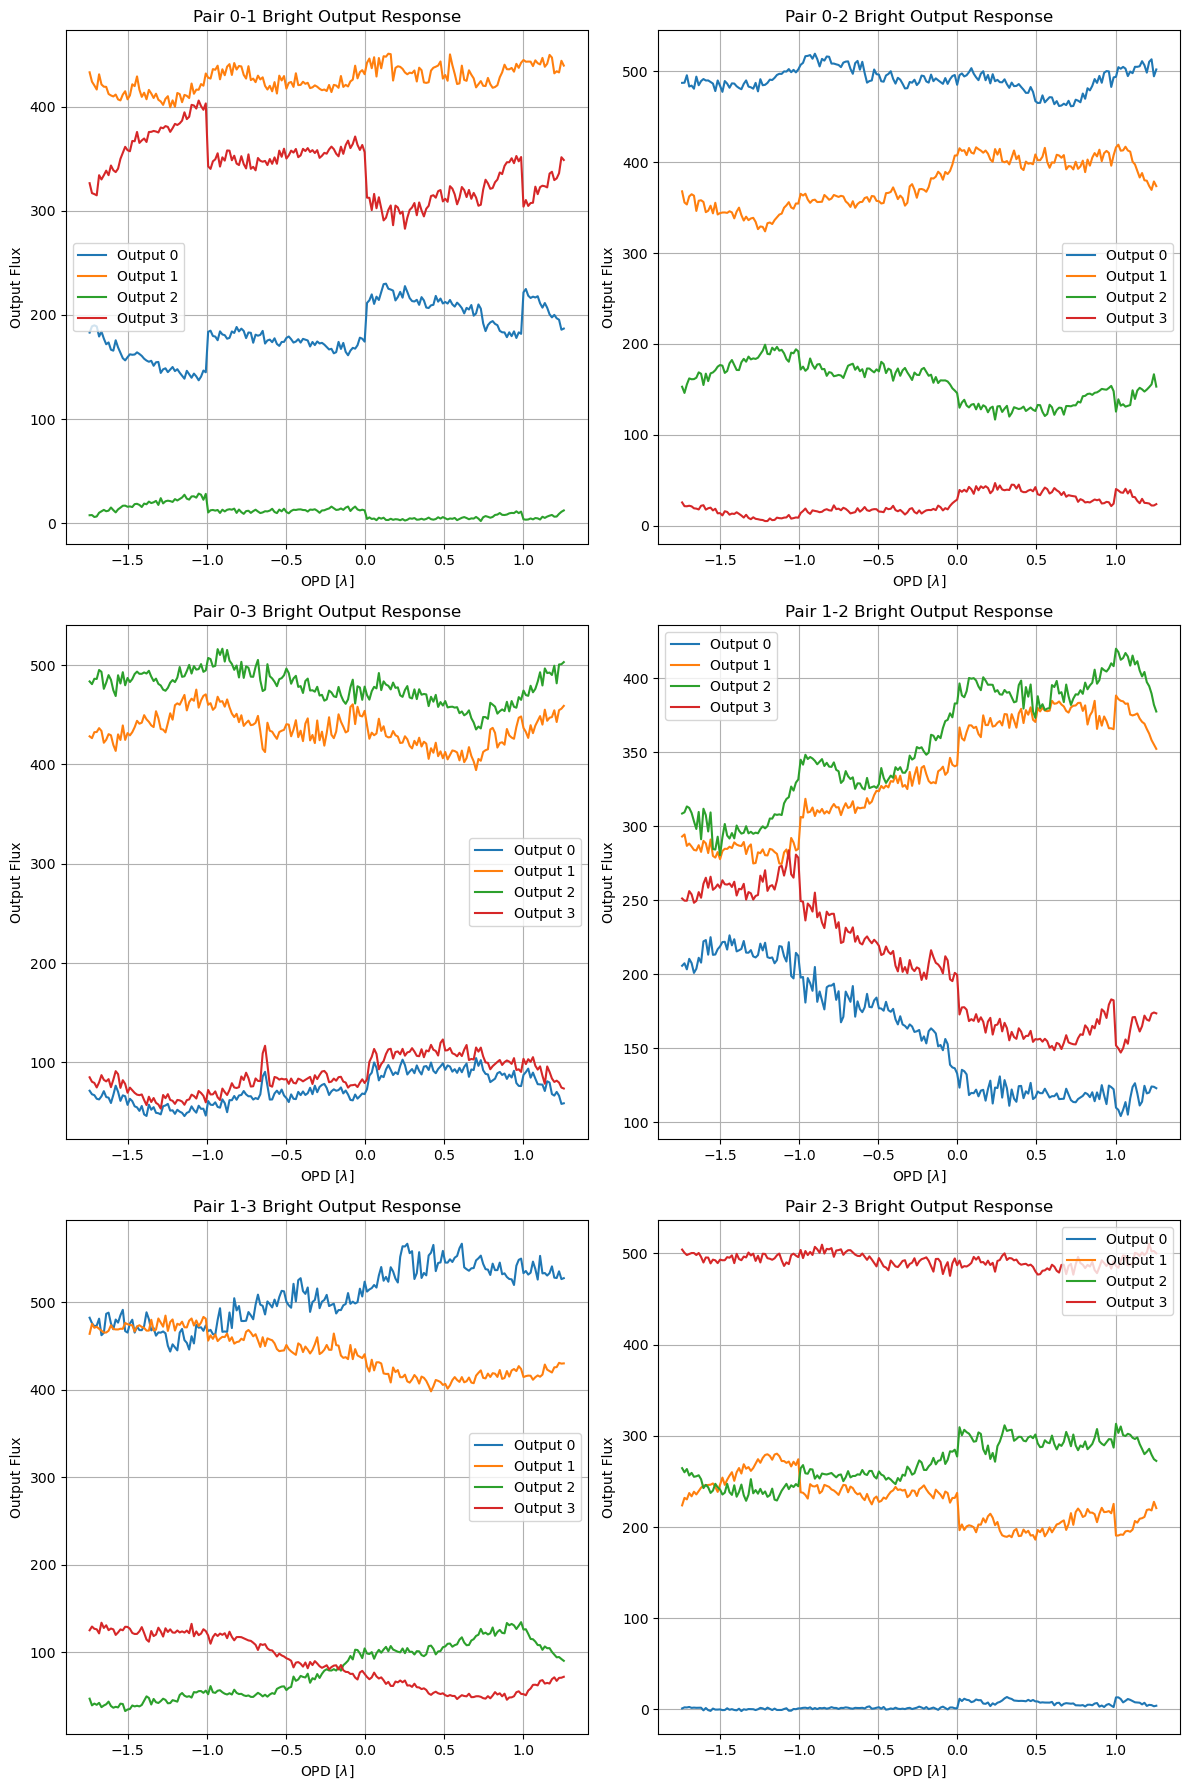

In [ ]:
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
start = -2500 # nm
nb_lam = 3.

piston_range = np.linspace(start, start + nb_lam * lam/2., 201)  # [nm]


res_ramp_scan = {}

fig, axs = plt.subplots(3, 2, figsize=(12, 18))
axs = axs.flatten()
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for i, pair in enumerate(pairs):

    inj.off()
    inj.set_balanced(np.array(pair))

    ref_cart = dm[inj_seg[pair[1]]].get_piston()
    opd_range = (piston_range - ref_cart) * 2

    dm[inj_seg[pair[1]]].set_piston(ref_cart)
    # Scan on first input
    outs = np.empty((len(piston_range), 4))
    for p, piston in enumerate(piston_range):
        phase = 2 * np.pi / lam * opd_range[p]
        phase = phase % (2 * np.pi)
        phases = np.zeros(4)
        phases[pair[0]] = phase
        chip.set_phases(phases)
        dm[inj_seg[pair[0]]].set_piston(piston)
        outs[p] = cam.get_outputs(flux_mode='mean')

    phases[pair[0]] = 0.
    chip.set_phases(phases)

    data = np.hstack((opd_range[:,None], outs.copy()))
    res_ramp_scan[(pair[0], pair[1])] = data

    for o in range(4):
        axs[i].plot(opd_range / lam, outs[:, o], color=colors[o], label=f'Output {o}')

    axs[i].set_title(f'Pair {pair[0]}-{pair[1]} Bright Output Response')
    axs[i].set_xlabel(r'OPD [$\lambda$]')
    axs[i].set_ylabel('Output Flux')
    axs[i].legend()
    axs[i].grid()
    

fig.tight_layout()
fig.savefig(path / 'ramp.png')

with open(path / 'ramp_scan_data.pkl', 'wb') as f:
    pickle.dump(res_ramp_scan, f)

inj.set_balanced()
chip.set_phases([0, 0, 0, 0])

# Upstream piston RMS regimes

In [68]:
def rms_scan(n, rms_values, wl, pair, correct_with_topas=False, plot=True):
    inj.off()
    chip.set_phases([0, 0, 0, 0])
    inj.set_balanced(pair)
    ref_carts = [dm[inj_seg[pair[0]]].get_piston(), dm[inj_seg[pair[1]]].get_piston()]
    ref_carts = np.array(ref_carts)
    print('Ref positions:', ref_carts)
    ref_tips = np.array([dm[inj_seg[pair[s]]].get_tip() for s in range(len(pair))])
    ref_tilts = np.array([dm[inj_seg[pair[s]]].get_tilt() for s in range(len(pair))])

    res = {}

    if plot:
        fig, axs = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle(f'Upstream Piston RMS Regimes - Pair {pair[0]}-{pair[1]}', fontsize=16)
        axs = axs.flatten()
        colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    else:
        fig = None

    for i, rms in enumerate(rms_values):

        print(f'Scanning RMS={rms} nm...')

        outs = np.empty((n, 4))
        res_pistons = np.empty((n, 2))
        res_phases = np.empty((n,))
        np.random.seed(0)
        for p in tqdm(range(n)):
            pistons = np.random.normal(ref_carts, rms, size=2)  # [nm]
            for s in range(len(pair)):
                # dm[inj_seg[pair[s]]].set_ptt(pistons[s], ref_tips[s], ref_tilts[s])
                dm[inj_seg[pair[s]]].set_piston(pistons[s])

            opd = (pistons[0] - pistons[1]) * 2
            phase = 2 * np.pi / wl * opd
            phase = phase % (2 * np.pi)
            phases = np.zeros(4)
            phases[pair[0]] = phase
            
            if correct_with_topas:
                chip.set_phases(phases)
                
            outs[p] = cam.get_outputs(flux_mode='mean')
            res_pistons[p] = pistons
            res_phases[p] = phases[pair[0]]

        res[rms] = {'flux':outs.copy(), 'pistons': res_pistons, 'phase':res_phases}

        if plot:
            for o in range(4):
                axs[i].hist(outs[:, o], bins=20, color=colors[o], alpha=0.7, label=f'Output {o}')
            axs[i].set_title(f'RMS {rms} nm Output Distribution')
            axs[i].set_xlabel('Output Flux')
            axs[i].set_ylabel('Counts')
            axs[i].legend()
            axs[i].grid()

    if plot:
        fig.tight_layout()

    chip.set_phases([0, 0, 0, 0])
    inj.set_balanced(pair)        

    return {'data': res, 'figure': fig}

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: [-1150. -1150.]
Scanning RMS=5 nm...


100%|██████████| 500/500 [00:12<00:00, 40.33it/s]


Injection BALANCED on channels [1, 3] (segments [137, 135])


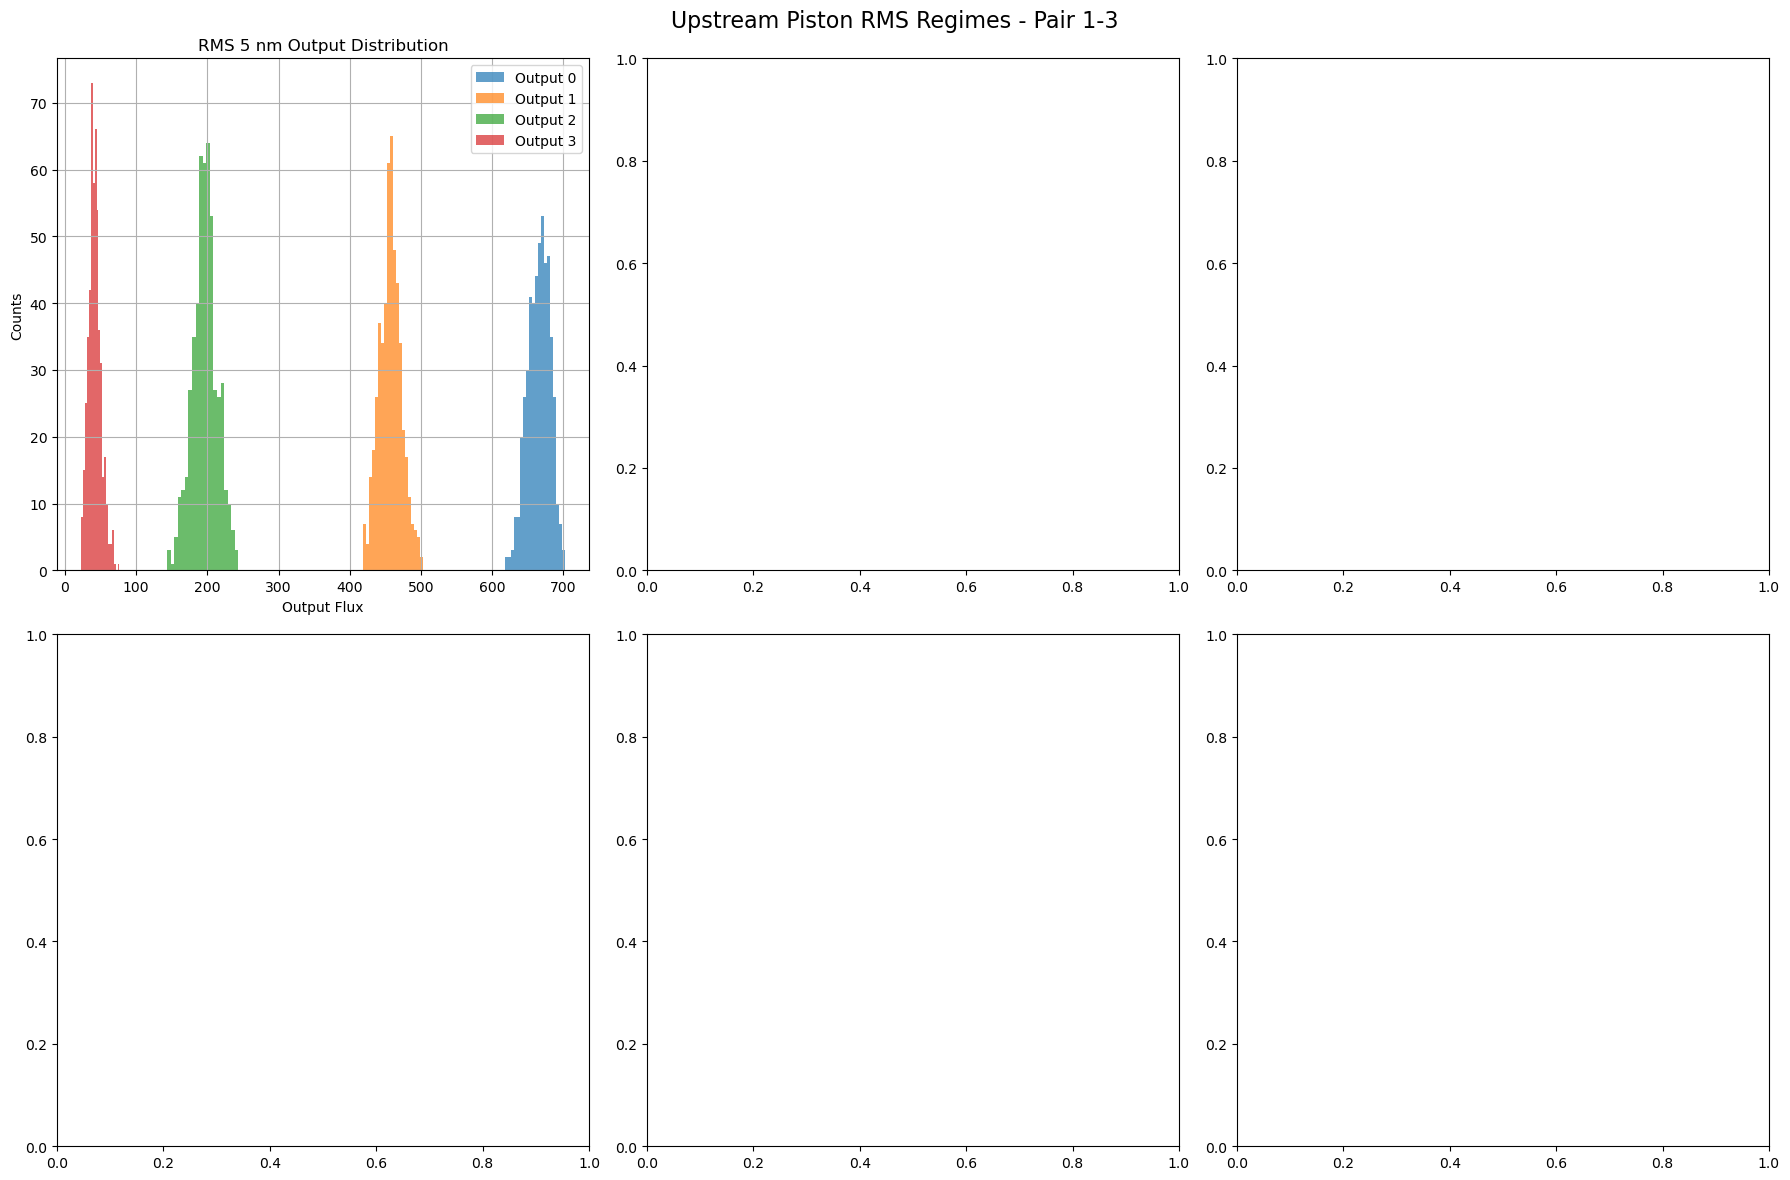

In [69]:
pair = (1, 3)
rms_values = [5, 10, 50, 100, 200] # [nm]
res_rms = rms_scan(500, rms_values[:1], lam, pair, False, True)

filename = 'fig_rms_pair_%s-%s.png'%(pair[0], pair[1])
try:
    res_rms['figure'].savefig(path / filename)
except:
    pass


In [70]:
filename = 'res_rms_pair_%s-%s.pkl'%(pair[0], pair[1])
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms, f)

# Same with TOPA correction

Injection OFF on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])
Injection BALANCED on channels [1, 3] (segments [137, 135])
Ref positions: [-1150. -1150.]
Scanning RMS=5 nm...


100%|██████████| 500/500 [01:55<00:00,  4.34it/s]


Injection BALANCED on channels [1, 3] (segments [137, 135])


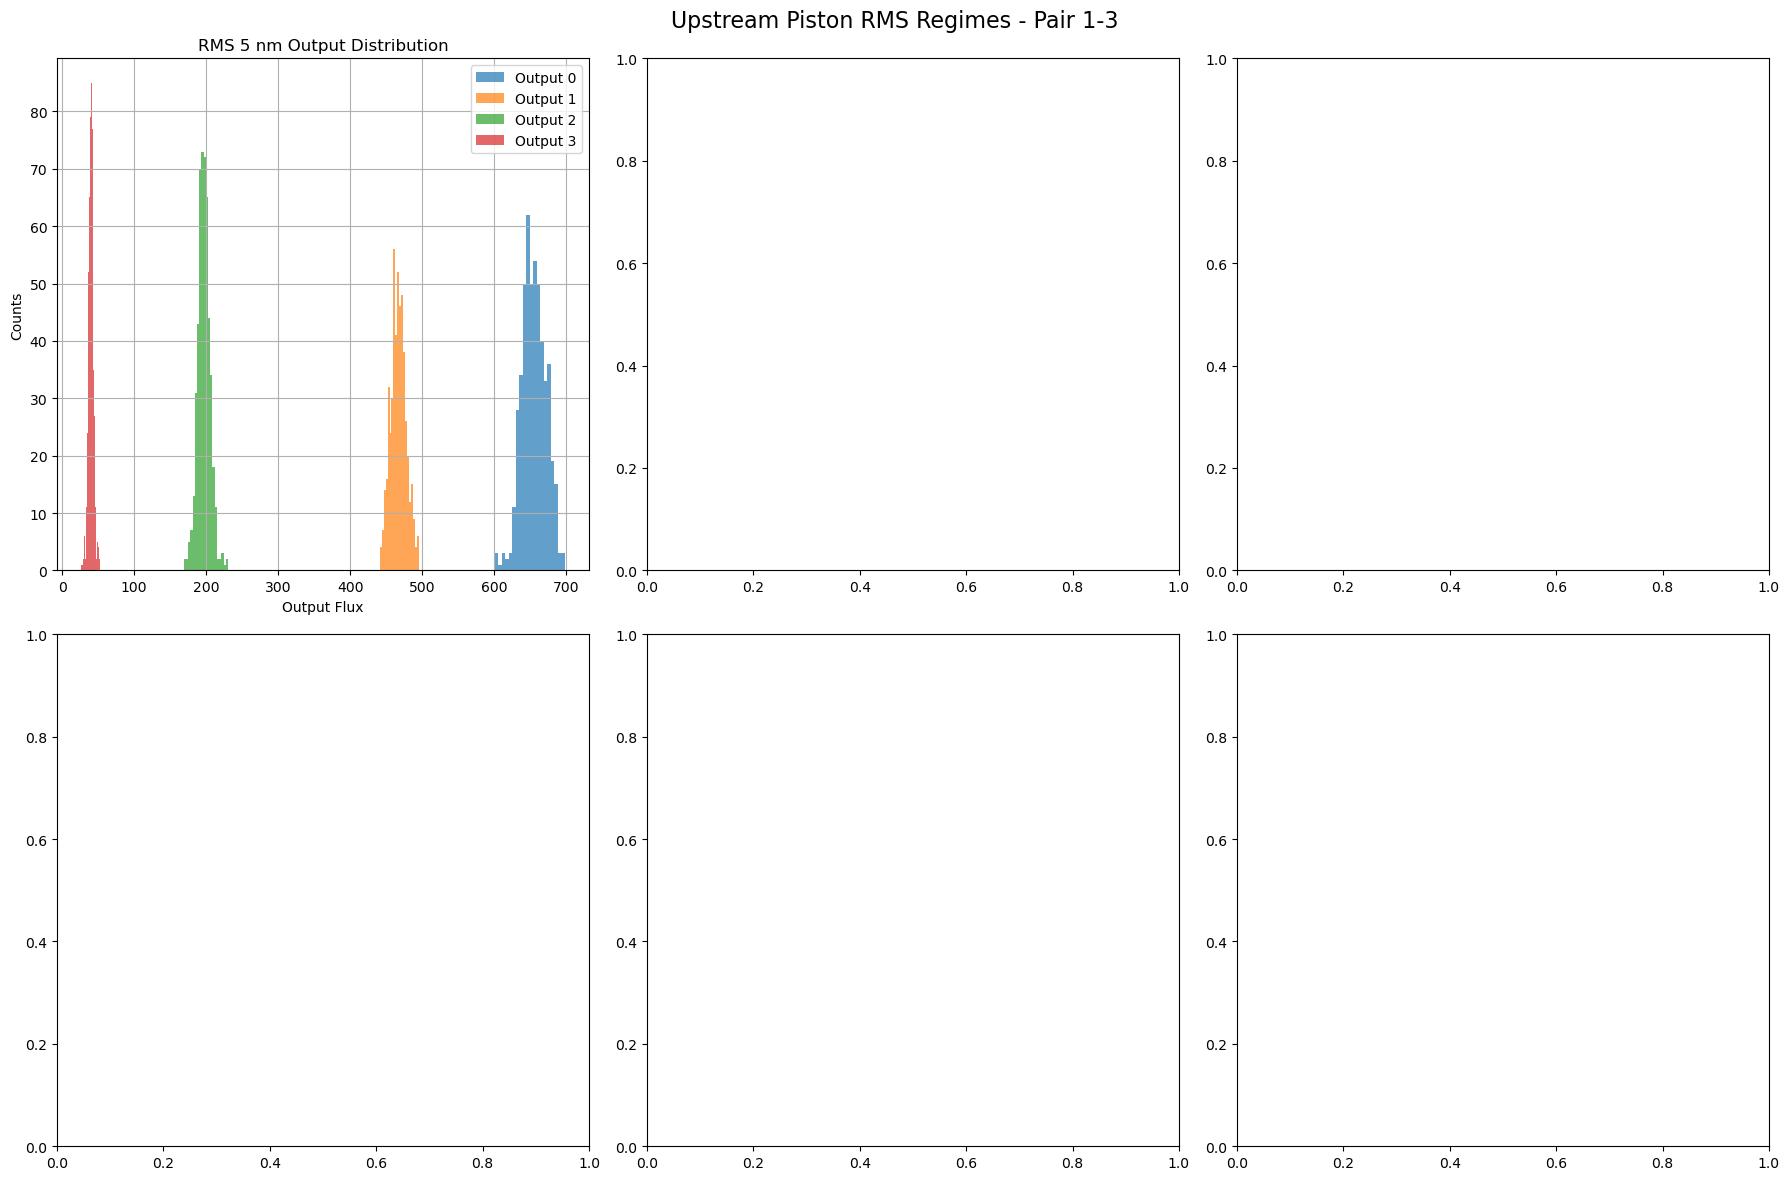

In [71]:
res_rms_corrected = rms_scan(500, rms_values[:1], lam, pair, True, True)
filename = 'fig_rms_corrected_pair_%s-%s.png'%(pair[0], pair[1])
res_rms_corrected['figure'].savefig(path / filename)

In [72]:
filename = 'res_rms_corrected_pair_%s-%s.pkl'%(pair[0], pair[1])
with open(path / filename, 'wb') as f:
    pickle.dump(res_rms_corrected, f)

# The end

In [73]:
phobos.XPOW().turn_off()
phobos.DM().zero()

Injection ZERO on channels [0, 1, 2, 3] (segments [138, 137, 136, 135])


/tmp/ipykernel_1041498/325630574.py:2: DeprecationWarning: DM.zero() is deprecated; use Injection().zero() instead.
  phobos.DM().zero()
